<a href="https://colab.research.google.com/github/gpreti/EE-629/blob/main/EX3_GraphMetrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

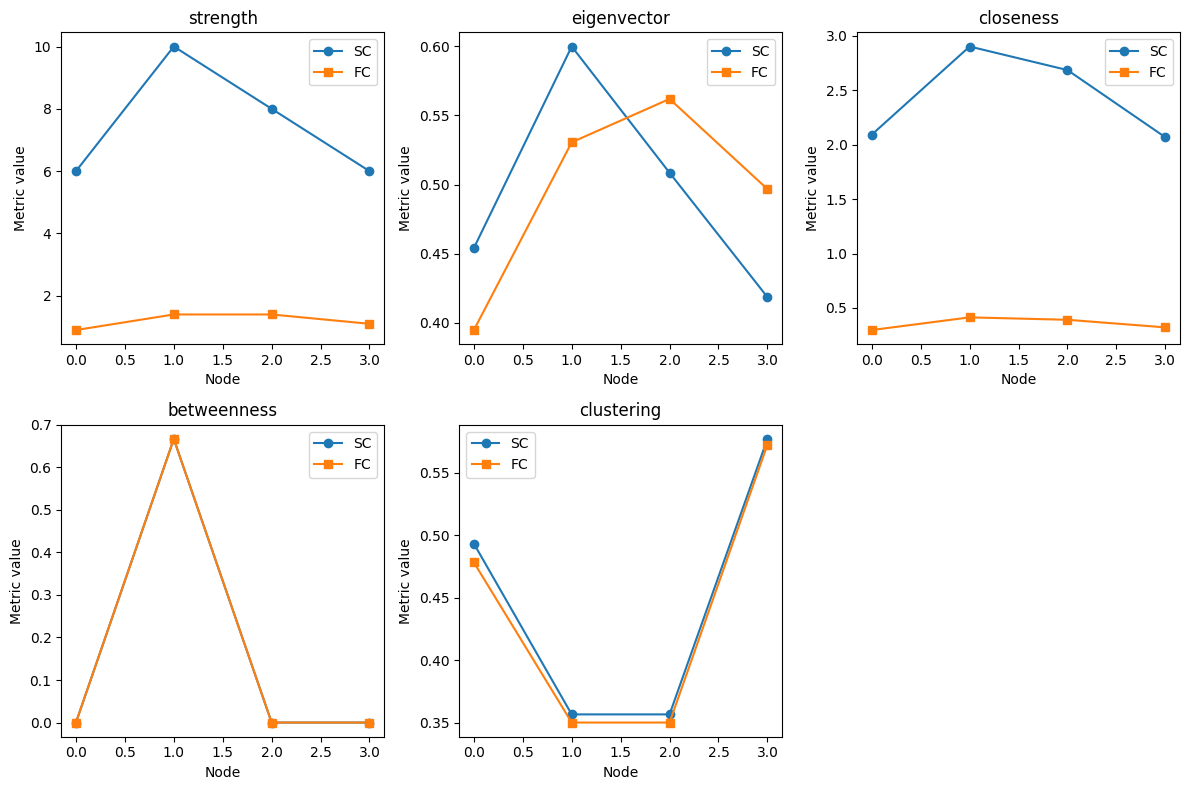

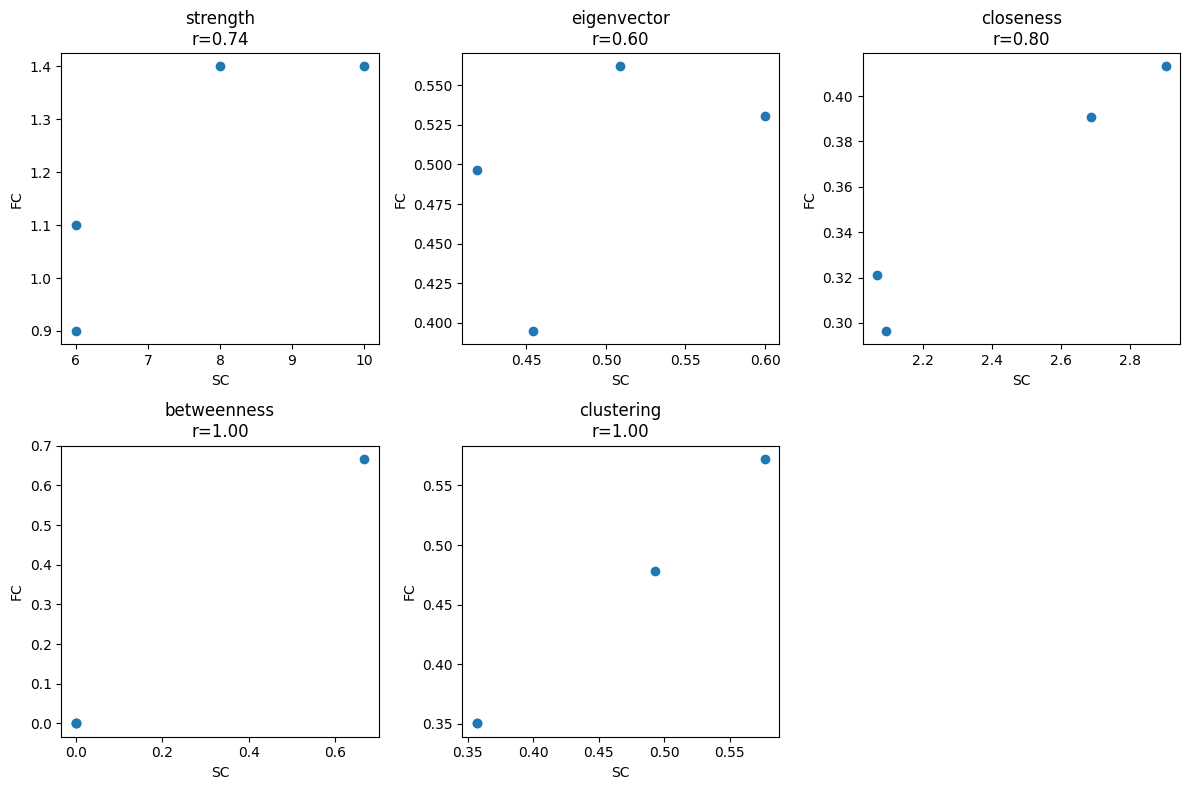

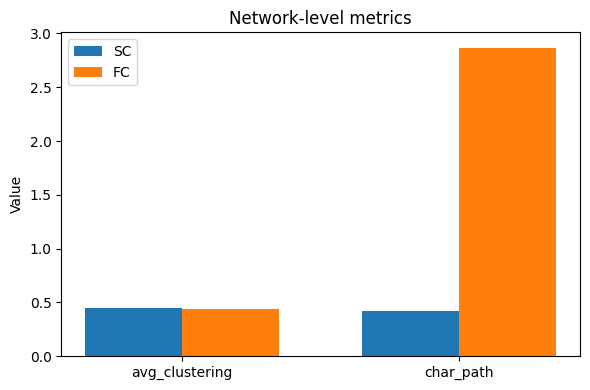

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Load Data

SC = np.array([
    [0, 5, 1, 0],
    [5, 0, 3, 2],
    [1, 3, 0, 4],
    [0, 2, 4, 0]
], dtype=float)

FC = np.array([
    [0, 0.7, 0.2, 0],
    [0.7, 0, 0.4, 0.3],
    [0.2, 0.4, 0, 0.8],
    [0, 0.3, 0.8, 0]
], dtype=float)


# --------------------------------------------------
# Convert weights to distances for path metrics
# --------------------------------------------------

def weight_to_distance(W):
    W = W.copy()
    W[W == 0] = np.nan
    D = 1 / W
    D[np.isnan(D)] = 0
    return D


# --------------------------------------------------
# Compute metrics
# --------------------------------------------------

def compute_metrics(W):

    G = nx.from_numpy_array(W)

    strength = dict(G.degree(weight='weight'))
    eigenvector = nx.eigenvector_centrality_numpy(G, weight='weight')
    clustering = nx.clustering(G, weight='weight')

    D = weight_to_distance(W)
    G_dist = nx.from_numpy_array(D)

    closeness = nx.closeness_centrality(G_dist, distance='weight')
    betweenness = nx.betweenness_centrality(G_dist, weight='weight')

    avg_clustering = nx.average_clustering(G, weight='weight')

    if nx.is_connected(G):
        char_path = nx.average_shortest_path_length(G_dist, weight='weight')
    else:
        char_path = np.nan

    metrics = {
        "strength": strength,
        "eigenvector": eigenvector,
        "closeness": closeness,
        "betweenness": betweenness,
        "clustering": clustering,
        "avg_clustering": avg_clustering,
        "char_path": char_path
    }

    return metrics


metrics_SC = compute_metrics(SC)
metrics_FC = compute_metrics(FC)


# --------------------------------------------------
# Prepare node metric arrays
# --------------------------------------------------

node_metrics = ["strength", "eigenvector", "closeness", "betweenness", "clustering"]

SC_values = {m: np.array(list(metrics_SC[m].values())) for m in node_metrics}
FC_values = {m: np.array(list(metrics_FC[m].values())) for m in node_metrics}

nodes = np.arange(len(SC))


# --------------------------------------------------
# Plot node metric profiles
# --------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, m in enumerate(node_metrics):

    axes[i].plot(nodes, SC_values[m], marker='o', label='SC')
    axes[i].plot(nodes, FC_values[m], marker='s', label='FC')

    axes[i].set_title(m)
    axes[i].set_xlabel("Node")
    axes[i].set_ylabel("Metric value")
    axes[i].legend()

axes[-1].axis("off")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Scatter plots (structure-function coupling)
# --------------------------------------------------

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, m in enumerate(node_metrics):

    x = SC_values[m]
    y = FC_values[m]

    r, p = spearmanr(x, y)

    axes[i].scatter(x, y)

    axes[i].set_xlabel("SC")
    axes[i].set_ylabel("FC")
    axes[i].set_title(f"{m}\nr={r:.2f}")

axes[-1].axis("off")

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Network-level comparison
# --------------------------------------------------

network_metrics = ["avg_clustering", "char_path"]

SC_net = [metrics_SC[m] for m in network_metrics]
FC_net = [metrics_FC[m] for m in network_metrics]

x = np.arange(len(network_metrics))
width = 0.35

plt.figure(figsize=(6,4))

plt.bar(x - width/2, SC_net, width, label="SC")
plt.bar(x + width/2, FC_net, width, label="FC")

plt.xticks(x, network_metrics)
plt.ylabel("Value")
plt.title("Network-level metrics")

plt.legend()

plt.tight_layout()
plt.show()